# Spanish + Legal Adaptation with DoRA

This notebook tests whether a Spanish-language adaptation and a legal-domain adaptation can be learned separately and then combined.

- Spanish factor: Spanish OPUS Books
- Legal factor: non-Spanish OPUS DGT
- Target: held-out Spanish OPUS DGT

The notebook uses `Qwen/Qwen3-0.6B-Base` with DoRA in all supported internal linear layers. Lower perplexity is better.

For a controlled factor comparison, Spanish Books and non-Spanish DGT are each sampled up to one million whitespace-tokenized training words. After model tokenization, both factor adapters are restricted to the same number of 512-token training blocks. Validation runs approximately every half epoch, and early stopping restores the best checkpoint.

**Kaggle:** enable a GPU and Internet, then run all cells.

## 1. Setup

In [1]:
# Keep Kaggle's working PyTorch/CUDA installation. Pin only the libraries used below.
%pip uninstall -y torchao

%pip install -q \
    "transformers==5.15.0" \
    "peft==0.20.0" \
    "datasets==5.0.1" \
    "accelerate>=1.8.0,<2" \
    safetensors sentencepiece

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 90.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 32.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import hashlib
import json
import math
import os
from pathlib import Path

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import peft
import torch
import torch.nn.functional as F
import transformers
from datasets import Dataset, load_dataset
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

assert torch.cuda.is_available(), "Enable a GPU in Kaggle before running the notebook."


### Experiment settings

In [3]:
# Fix all random generators used by Transformers, PyTorch, and NumPy-backed utilities.
SEED = 42
set_seed(SEED)

GPU_NAME = torch.cuda.get_device_name(0)
GPU_COUNT = torch.cuda.device_count()
TRAIN_WORLD_SIZE = max(GPU_COUNT, int(os.environ.get("WORLD_SIZE", "1")))
USE_BF16 = bool(torch.cuda.is_bf16_supported())
MODEL_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16

print("GPU:", GPU_NAME)
print("Visible training GPUs:", GPU_COUNT)
print("Training world size:", TRAIN_WORLD_SIZE)
print("Training dtype:", MODEL_DTYPE)
print("Versions:", {
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "peft": peft.__version__,
    "datasets": datasets.__version__,
})


GPU: Tesla T4
Visible training GPUs: 2
Training world size: 2
Training dtype: torch.bfloat16
Versions: {'torch': '2.10.0+cu128', 'transformers': '5.15.0', 'peft': '0.20.0', 'datasets': '5.0.1'}


In [4]:
MODEL_ID = "Qwen/Qwen3-0.6B-Base"
BOOKS_ID = "Helsinki-NLP/opus_books"
DGT_ID = "Helsinki-NLP/opus_dgt"

# Use fixed OPUS configurations so a later dataset update cannot change the selected pairs.
SPANISH_BOOKS_CONFIG = "en-es"
SPANISH_DGT_CONFIG = "es-ga"
TARGET_LANGUAGE = "es"

# Select one fixed DGT pair for each non-Spanish legal-language sample.
LEGAL_SOURCES = {
    "bg": "bg-ga",
    "fi": "fi-ga",
    "ga": "bg-ga",
    "hr": "bg-hr",
    "mt": "mt-sh",
    "nl": "ga-nl",
    "sh": "bg-sh",
    "sk": "hr-sk",
    "sv": "hr-sv",
}

WORK_DIR = Path("/kaggle/working/elma_spanish_dora_improved")
ADAPTER_DIR = WORK_DIR / "adapters"
RESULT_DIR = WORK_DIR / "results"
for path in (ADAPTER_DIR, RESULT_DIR):
    path.mkdir(parents=True, exist_ok=True)

# Give the two independent factors equal raw-text and validation budgets.
LANGUAGE_WORD_BUDGET = 1_000_000
GENRE_WORD_BUDGET = 1_000_000
FACTOR_VALID_WORD_BUDGET = 100_000

# Keep the target training corpus within a one-million-word budget.
TARGET_TRAIN_WORD_CAP = 1_000_000
TARGET_VALID_WORD_BUDGET = 100_000
TARGET_TEST_WORD_BUDGET = 100_000

BLOCK_SIZE = 512
DORA_RANK = 8
DORA_ALPHA = 16
LEARNING_RATE = 2e-4
MAX_EPOCHS = 3.0
EVALUATIONS_PER_EPOCH = 2
EARLY_STOPPING_PATIENCE = 2
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION = 32
EVAL_BATCH_SIZE = 1
REUSE_EXISTING = False

# Save the complete experiment configuration beside the generated results.
run_config = {
    "model_id": MODEL_ID,
    "spanish_books_config": SPANISH_BOOKS_CONFIG,
    "spanish_dgt_config": SPANISH_DGT_CONFIG,
    "legal_sources": LEGAL_SOURCES,
    "language_word_budget": LANGUAGE_WORD_BUDGET,
    "genre_word_budget": GENRE_WORD_BUDGET,
    "factor_valid_word_budget": FACTOR_VALID_WORD_BUDGET,
    "target_train_word_cap": TARGET_TRAIN_WORD_CAP,
    "target_valid_word_budget": TARGET_VALID_WORD_BUDGET,
    "target_test_word_budget": TARGET_TEST_WORD_BUDGET,
    "block_size": BLOCK_SIZE,
    "dora_rank": DORA_RANK,
    "dora_alpha": DORA_ALPHA,
    "learning_rate": LEARNING_RATE,
    "max_epochs": MAX_EPOCHS,
    "evaluations_per_epoch": EVALUATIONS_PER_EPOCH,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "train_world_size": TRAIN_WORLD_SIZE,
    "seed": SEED,
}
(RESULT_DIR / "run_config.json").write_text(json.dumps(run_config, indent=2), encoding="utf-8")


728

## 2. Data

The language-pair configurations are fixed above, so the run cannot silently switch datasets.

- Spanish Books and non-Spanish DGT are each sampled up to 1M training words, with separate 100k-word validation samples.
- After tokenization, the factor training sets are reduced to the same number of 512-token blocks. This equalizes model-token exposure and optimizer steps.
- Packed blocks are shuffled before downsampling so every legal source language remains represented.
- All adapter runs use equally sized validation-block sets, keeping validation cost comparable.
- Spanish DGT uses a 1M-word training budget plus separate 100k-word validation and test budgets.

The multilingual legal sample is balanced by raw word count and limited to a practical training size. Splits are deterministic, and duplicate normalized texts are removed before selection.


In [5]:
def clean_text(text):
    """Normalize whitespace so duplicate checks compare stable text strings."""
    return " ".join(str(text).split())


def translation_stream(dataset_id, config_name):
    """Load and deterministically shuffle one OPUS translation stream."""
    dataset = load_dataset(dataset_id, config_name, split="train", streaming=True)
    return dataset.shuffle(seed=SEED, buffer_size=10_000)


def collect_train_validation_words(
    dataset_id,
    config_name,
    language,
    train_budget,
    valid_budget,
    seen_texts=None,
):
    """Collect disjoint train and validation texts up to fixed word budgets."""
    train_texts, valid_texts = [], []
    train_words = valid_words = 0
    seen_texts = set() if seen_texts is None else seen_texts

    for row in translation_stream(dataset_id, config_name):
        text = clean_text(row.get("translation", {}).get(language, ""))
        words = text.split()
        if len(words) < 4 or text in seen_texts:
            continue
        seen_texts.add(text)

        if train_words < train_budget:
            selected = words[: train_budget - train_words]
            train_texts.append(" ".join(selected))
            train_words += len(selected)
            # Keep a source document on only one side of the train/validation boundary.
            continue

        selected = words[: valid_budget - valid_words]
        if selected:
            valid_texts.append(" ".join(selected))
            valid_words += len(selected)
        if valid_words >= valid_budget:
            break
    return train_texts, valid_texts, train_words, valid_words


def trim_to_word_budget(texts, word_budget):
    """Trim an ordered text collection to an exact maximum word count."""
    selected, word_count = [], 0
    for text in texts:
        words = text.split()[: word_budget - word_count]
        if words:
            selected.append(" ".join(words))
            word_count += len(words)
        if word_count >= word_budget:
            break
    return selected, word_count


def target_split(text):
    """Assign normalized text deterministically to an 80/10/10 split."""
    bucket = int(hashlib.sha1(text.encode("utf-8")).hexdigest()[:8], 16) % 100
    return "train" if bucket < 80 else "validation" if bucket < 90 else "test"


def collect_target_splits():
    """Build disjoint Spanish DGT splits until each word budget is filled."""
    caps = {
        "train": TARGET_TRAIN_WORD_CAP,
        "validation": TARGET_VALID_WORD_BUDGET,
        "test": TARGET_TEST_WORD_BUDGET,
    }
    texts = {split: [] for split in caps}
    counts = {split: 0 for split in caps}
    seen = set()

    for row in translation_stream(DGT_ID, SPANISH_DGT_CONFIG):
        text = clean_text(row.get("translation", {}).get(TARGET_LANGUAGE, ""))
        if len(text.split()) < 4 or text in seen:
            continue
        seen.add(text)
        split = target_split(text)
        remaining = caps[split] - counts[split]
        if remaining <= 0:
            continue
        words = text.split()[:remaining]
        if words:
            texts[split].append(" ".join(words))
            counts[split] += len(words)
        if all(counts[name] >= caps[name] for name in caps):
            break

    return texts, counts


### Load the three corpora

In [7]:
# Collect the Spanish language factor and the Spanish legal target splits.
language_train_texts, language_valid_texts, language_train_words, language_valid_words = (
    collect_train_validation_words(
        BOOKS_ID,
        SPANISH_BOOKS_CONFIG,
        TARGET_LANGUAGE,
        LANGUAGE_WORD_BUDGET,
        FACTOR_VALID_WORD_BUDGET,
    )
)
target_texts, target_word_counts = collect_target_splits()

# Give every non-Spanish legal language an equal share of each raw-text budget.
per_language_train = math.ceil(GENRE_WORD_BUDGET / len(LEGAL_SOURCES))
per_language_valid = math.ceil(FACTOR_VALID_WORD_BUDGET / len(LEGAL_SOURCES))
genre_train_parts, genre_valid_parts, genre_rows = [], [], []

# A shared set prevents normalized text from crossing languages or data splits.
genre_seen_texts = set()
for language, config_name in LEGAL_SOURCES.items():
    train, valid, train_words, valid_words = collect_train_validation_words(
        DGT_ID,
        config_name,
        language,
        per_language_train,
        per_language_valid,
        seen_texts=genre_seen_texts,
    )
    genre_train_parts.extend(train)
    genre_valid_parts.extend(valid)
    genre_rows.append({
        "language": language,
        "config": config_name,
        "train_words": train_words,
        "validation_words": valid_words,
        "train_documents": len(train),
        "validation_documents": len(valid),
    })

genre_train_texts, genre_train_words = trim_to_word_budget(
    genre_train_parts, GENRE_WORD_BUDGET
)
genre_valid_texts, genre_valid_words = trim_to_word_budget(
    genre_valid_parts, FACTOR_VALID_WORD_BUDGET
)

# Record corpus sizes before model tokenization and block packing.
data_summary = pd.DataFrame([
    {"corpus": "Spanish Books train", "documents": len(language_train_texts), "words": language_train_words},
    {"corpus": "Spanish Books validation", "documents": len(language_valid_texts), "words": language_valid_words},
    {"corpus": "Non-Spanish DGT train", "documents": len(genre_train_texts), "words": genre_train_words},
    {"corpus": "Non-Spanish DGT validation", "documents": len(genre_valid_texts), "words": genre_valid_words},
    {"corpus": "Spanish DGT train", "documents": len(target_texts["train"]), "words": target_word_counts["train"]},
    {"corpus": "Spanish DGT validation", "documents": len(target_texts["validation"]), "words": target_word_counts["validation"]},
    {"corpus": "Spanish DGT test", "documents": len(target_texts["test"]), "words": target_word_counts["test"]},
])

# Fail early if a duplicate crosses any train, validation, or test boundary.
assert target_word_counts["train"] <= TARGET_TRAIN_WORD_CAP
assert set(target_texts["train"]).isdisjoint(target_texts["validation"])
assert set(target_texts["train"]).isdisjoint(target_texts["test"])
assert set(target_texts["validation"]).isdisjoint(target_texts["test"])
assert set(language_train_texts).isdisjoint(language_valid_texts)
assert len(genre_train_texts) == len(set(genre_train_texts))
assert len(genre_valid_texts) == len(set(genre_valid_texts))
assert set(genre_train_texts).isdisjoint(genre_valid_texts)
assert TARGET_LANGUAGE not in LEGAL_SOURCES
assert SPANISH_DGT_CONFIG not in LEGAL_SOURCES.values()

pd.DataFrame(genre_rows).to_csv(RESULT_DIR / "genre_language_sampling.csv", index=False)
data_summary.to_csv(RESULT_DIR / "data_summary.csv", index=False)
display(data_summary)


,corpus,documents,words
0,Spanish Books train,37317,1000000
1,Spanish Books validation,4663,100000
2,Non-Spanish DGT train,46827,1000000
3,Non-Spanish DGT validation,4861,100000
4,Spanish DGT train,32466,1000000
5,Spanish DGT validation,3296,100000
6,Spanish DGT test,3228,100000


### Pack and equalize 512-token blocks

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token


def pack_texts(texts, block_size=BLOCK_SIZE, batch_size=256):
    """Tokenize texts, insert EOS separators, and pack complete fixed-size blocks."""
    blocks, remainder = [], []
    eos_id = tokenizer.eos_token_id
    for start in range(0, len(texts), batch_size):
        encoded = tokenizer(
            texts[start:start + batch_size],
            add_special_tokens=False,
            truncation=False,
        )["input_ids"]
        for token_ids in encoded:
            remainder.extend(token_ids)
            if eos_id is not None:
                remainder.append(eos_id)
        complete = (len(remainder) // block_size) * block_size
        if complete:
            blocks.extend(
                remainder[index:index + block_size]
                for index in range(0, complete, block_size)
            )
            remainder = remainder[complete:]
    if not blocks:
        raise ValueError("Corpus is too small to create one complete block.")
    return Dataset.from_dict({"input_ids": blocks})


# Tokenize and pack every corpus before equalizing model-token exposure.
language_train_blocks = pack_texts(language_train_texts)
language_valid_blocks = pack_texts(language_valid_texts)
genre_train_blocks = pack_texts(genre_train_texts)
genre_valid_blocks = pack_texts(genre_valid_texts)
target_train_blocks = pack_texts(target_texts["train"])
target_valid_blocks = pack_texts(target_texts["validation"])
target_test_blocks = pack_texts(target_texts["test"])

available_block_counts = {
    "language_train": len(language_train_blocks),
    "genre_train": len(genre_train_blocks),
    "language_validation": len(language_valid_blocks),
    "genre_validation": len(genre_valid_blocks),
    "target_train": len(target_train_blocks),
    "target_validation": len(target_valid_blocks),
    "target_test": len(target_test_blocks),
}

# Shuffle before selecting a common size. This avoids taking only the first
# languages from the legal corpus when its model-tokenized form is longer.
language_train_blocks = language_train_blocks.shuffle(seed=SEED)
genre_train_blocks = genre_train_blocks.shuffle(seed=SEED)
factor_train_block_count = min(len(language_train_blocks), len(genre_train_blocks))
language_train_blocks = language_train_blocks.select(range(factor_train_block_count))
genre_train_blocks = genre_train_blocks.select(range(factor_train_block_count))

# Shuffle and equalize validation sets so each training run has the same cost.
language_valid_blocks = language_valid_blocks.shuffle(seed=SEED + 1)
genre_valid_blocks = genre_valid_blocks.shuffle(seed=SEED + 1)
target_valid_blocks = target_valid_blocks.shuffle(seed=SEED + 1)
validation_block_count = min(
    len(language_valid_blocks),
    len(genre_valid_blocks),
    len(target_valid_blocks),
)
language_valid_blocks = language_valid_blocks.select(range(validation_block_count))
genre_valid_blocks = genre_valid_blocks.select(range(validation_block_count))
target_valid_blocks = target_valid_blocks.select(range(validation_block_count))

assert len(language_train_blocks) == len(genre_train_blocks)
assert len(language_valid_blocks) == len(genre_valid_blocks) == len(target_valid_blocks)

# Show both the packed size and the final size used by each run.
used_block_counts = {
    "language_train": len(language_train_blocks),
    "genre_train": len(genre_train_blocks),
    "language_validation": len(language_valid_blocks),
    "genre_validation": len(genre_valid_blocks),
    "target_train": len(target_train_blocks),
    "target_validation": len(target_valid_blocks),
    "target_test": len(target_test_blocks),
}
block_summary = pd.DataFrame([
    {
        "dataset": name,
        "blocks_available": available_block_counts[name],
        "blocks_used": used_block_counts[name],
    }
    for name in available_block_counts
])
block_summary.to_csv(RESULT_DIR / "block_summary.csv", index=False)
display(block_summary)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,dataset,blocks_available,blocks_used
0,language_train,3263,3263
1,genre_train,5824,3263
2,language_validation,334,327
3,genre_validation,583,327
4,target_train,3272,3272
5,target_validation,327,327
6,target_test,326,326


## 3. Train the DoRA adapters

The Spanish and legal adapters start from identical backbone weights and use the same number of training blocks. Each run is evaluated approximately twice per epoch; the optimizer-step interval accounts for the training-set size, gradient accumulation, and number of GPUs. Training lasts at most five epochs, stops after two consecutive validation checks without improvement, and restores the best checkpoint.


In [8]:
training_histories = {}


def clear_memory():
    """Release Python and CUDA objects between sequential model runs."""
    gc.collect()
    torch.cuda.empty_cache()


def load_base(model_id=MODEL_ID, device="cuda", dtype=MODEL_DTYPE):
    """Load a clean causal language model in the requested dtype and device."""
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=dtype,
        low_cpu_mem_usage=True,
    )
    model.config.use_cache = False
    if device is not None:
        model.to(device)
    return model


def dora_config():
    """Configure DoRA for every supported internal linear layer."""
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=DORA_RANK,
        lora_alpha=DORA_ALPHA,
        lora_dropout=0.05,
        target_modules="all-linear",
        bias="none",
        use_dora=True,
    )


def training_arguments(run_name, train_dataset_size):
    """Build Trainer settings with approximately two validations per epoch."""
    effective_batch_size = (
        TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION * TRAIN_WORLD_SIZE
    )
    updates_per_epoch = math.ceil(train_dataset_size / effective_batch_size)
    eval_steps = max(1, math.ceil(updates_per_epoch / EVALUATIONS_PER_EPOCH))
    print(
        f"Effective batch size: {effective_batch_size}; "
        f"evaluation every {eval_steps} optimizer steps "
        f"(~{EVALUATIONS_PER_EPOCH} times per epoch)."
    )

    return TrainingArguments(
        output_dir=str(WORK_DIR / "trainer" / run_name),
        num_train_epochs=MAX_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_steps=0,
        weight_decay=0.01,
        max_grad_norm=1.0,
        logging_steps=10,
        eval_strategy="steps",
        save_strategy="steps",
        eval_steps=eval_steps,
        save_steps=eval_steps,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        fp16=not USE_BF16,
        bf16=USE_BF16,
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=2,
        seed=SEED,
    )


def train_new_dora(
    train_dataset,
    validation_dataset,
    output_dir,
    run_name,
    base_model_id=MODEL_ID,
):
    """Train one independent DoRA adapter and save its metrics and best weights."""
    output_dir = Path(output_dir)
    history_path = RESULT_DIR / f"{run_name}_training_log.csv"
    if REUSE_EXISTING and (output_dir / "adapter_config.json").exists():
        print("Reusing:", output_dir)
        if history_path.exists():
            training_histories[run_name] = pd.read_csv(history_path)
        return

    model = get_peft_model(load_base(model_id=base_model_id), dora_config())
    dora_layer_count = sum(
        1
        for module in model.modules()
        if hasattr(module, "lora_magnitude_vector")
        and len(module.lora_magnitude_vector) > 0
    )
    assert dora_layer_count > 0, "No DoRA layers were created."
    print("DoRA-wrapped linear layers:", dora_layer_count)
    model.print_trainable_parameters()

    trainer = Trainer(
        model=model,
        args=training_arguments(run_name, len(train_dataset)),
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        data_collator=data_collator,
        processing_class=tokenizer,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=EARLY_STOPPING_PATIENCE,
                early_stopping_threshold=0.0,
            )
        ],
    )
    trainer.train()

    # Trainer restores the best checkpoint before the final adapter is saved.
    output_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(output_dir, safe_serialization=True)
    tokenizer.save_pretrained(output_dir)

    history = pd.DataFrame(trainer.state.log_history)
    training_histories[run_name] = history.copy()
    history.to_csv(history_path, index=False)
    best_run = {
        "run": run_name,
        "evaluation_interval_steps": trainer.args.eval_steps,
        "best_validation_loss": trainer.state.best_metric,
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "completed_epochs": trainer.state.epoch,
    }
    (RESULT_DIR / f"{run_name}_best_checkpoint.json").write_text(
        json.dumps(best_run, indent=2), encoding="utf-8"
    )
    if "eval_loss" in history.columns:
        display(history.loc[history["eval_loss"].notna(), ["epoch", "eval_loss"]])

    del trainer, model
    clear_memory()


In [9]:
LANGUAGE_ADAPTER = ADAPTER_DIR / "spanish_books_dora"
GENRE_ADAPTER = ADAPTER_DIR / "non_spanish_dgt_dora"
TARGET_ADAPTER = ADAPTER_DIR / "spanish_dgt_direct_dora"

train_new_dora(
    language_train_blocks,
    language_valid_blocks,
    LANGUAGE_ADAPTER,
    "language_spanish_books",
)
train_new_dora(
    genre_train_blocks,
    genre_valid_blocks,
    GENRE_ADAPTER,
    "genre_non_spanish_dgt",
)
train_new_dora(
    target_train_blocks,
    target_valid_blocks,
    TARGET_ADAPTER,
    "target_spanish_dgt_direct",
)

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DoRA-wrapped linear layers: 196
trainable params: 5,390,336 || all params: 601,440,256 || trainable%: 0.8962
Effective batch size: 64; evaluation every 26 optimizer steps (~2 times per epoch).


...

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DoRA-wrapped linear layers: 196
trainable params: 5,390,336 || all params: 601,440,256 || trainable%: 0.8962
Effective batch size: 64; evaluation every 26 optimizer steps (~2 times per epoch).


Step,Training Loss,Validation Loss
26,2.258461,2.175373
52,2.079511,2.075753
78,2.020407,2.027993
104,1.988932,2.003085
130,1.956891,1.993610
156,1.948731,1.992096


,epoch,eval_loss
2,0.508557,2.175373
6,1.000000,2.075753
9,1.508557,2.027993
13,2.000000,2.003085
17,2.508557,1.993610
20,3.000000,1.992096


## 4. Evaluate on held-out Spanish DGT

In [10]:
@torch.inference_mode()
def evaluate_block_losses(model, dataset, batch_size=EVAL_BATCH_SIZE):
    """Return one mean next-token loss for every fixed-size evaluation block."""
    model.eval()
    model.config.use_cache = False
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=data_collator,
    )
    block_losses = []
    for batch in loader:
        batch = {key: value.to(model.device) for key, value in batch.items()}
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch.get("attention_mask"),
        )
        shift_logits = outputs.logits[:, :-1, :].float()
        shift_labels = batch["input_ids"][:, 1:]
        token_losses = F.cross_entropy(
            shift_logits.transpose(1, 2),
            shift_labels,
            reduction="none",
        )
        block_losses.extend(token_losses.mean(dim=1).cpu().tolist())
        del outputs, shift_logits, token_losses
    return np.asarray(block_losses, dtype=np.float64)


def bootstrap_ppl_ci(block_losses, samples=5_000, seed=SEED):
    """Estimate a 95% confidence interval for perplexity by resampling blocks."""
    rng = np.random.default_rng(seed)
    means = np.empty(samples, dtype=np.float64)
    for index in range(samples):
        means[index] = rng.choice(
            block_losses,
            size=len(block_losses),
            replace=True,
        ).mean()
    lower_nll, upper_nll = np.quantile(means, [0.025, 0.975])
    return float(np.exp(lower_nll)), float(np.exp(upper_nll))


evaluation_losses = {}


def record_evaluation(name, model):
    """Evaluate a model and retain both summary metrics and paired block losses."""
    losses = evaluate_block_losses(model, target_test_blocks)
    evaluation_losses[name] = losses
    mean_nll = float(losses.mean())
    ppl_low, ppl_high = bootstrap_ppl_ci(losses)
    row = {
        "model": name,
        "mean_nll": mean_nll,
        "perplexity": float(np.exp(mean_nll)),
        "ppl_ci_low": ppl_low,
        "ppl_ci_high": ppl_high,
        "test_blocks": len(losses),
    }
    print(row)
    return row


def load_merged_adapter(
    adapter_path,
    device="cuda",
    dtype=MODEL_DTYPE,
    base_model_id=MODEL_ID,
):
    """Load one DoRA adapter, merge it into its backbone, and remove PEFT wrappers."""
    base = load_base(model_id=base_model_id, device=device, dtype=dtype)
    adapted = PeftModel.from_pretrained(base, adapter_path, is_trainable=False)
    merged = adapted.merge_and_unload(safe_merge=True)
    merged.config.use_cache = False
    return merged


### Base and single-adapter baselines

In [11]:
result_rows = []
evaluation_models = [
    ("Base", None),
    ("Spanish DoRA", LANGUAGE_ADAPTER),
    ("Legal DoRA", GENRE_ADAPTER),
    ("Direct Spanish-legal DoRA", TARGET_ADAPTER),
]

for name, adapter_path in evaluation_models:
    model = load_base() if adapter_path is None else load_merged_adapter(adapter_path)
    result_rows.append(record_evaluation(name, model))
    del model
    clear_memory()

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

{'model': 'Base', 'mean_nll': 2.546217585268196, 'perplexity': 12.75875350269361, 'ppl_ci_low': 12.461601126900728, 'ppl_ci_high': 13.05002891629825, 'test_blocks': 326}


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

{'model': 'Spanish DoRA', 'mean_nll': 2.8370991491832616, 'perplexity': 17.06618719915601, 'ppl_ci_low': 16.598224392410565, 'ppl_ci_high': 17.52618217494905, 'test_blocks': 326}


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

{'model': 'Legal DoRA', 'mean_nll': 2.5571868181959982, 'perplexity': 12.899477648661898, 'ppl_ci_low': 12.611421307377535, 'ppl_ci_high': 13.178598015314522, 'test_blocks': 326}


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

{'model': 'Direct Spanish-legal DoRA', 'mean_nll': 2.098287061679583, 'perplexity': 8.152193740770853, 'ppl_ci_low': 7.942096450056706, 'ppl_ci_high': 8.360238728536459, 'test_blocks': 326}


### Zero-shot composition

DoRA changes both weight direction and magnitude, so adding only its low-rank matrices is incomplete. Each adapter is first merged into a clean backbone, then the full parameter deltas are added:

$$W_{\text{composed}} = W_{\text{Spanish}} + W_{\text{legal}} - W_{\text{base}}.$$

No Spanish DGT training text is used at this stage. PEFT performs the individual DoRA merges; the short task-arithmetic function below is needed because PEFT does not directly add two fully merged DoRA deltas.

In [12]:
COMPOSED_MODEL_DIR = WORK_DIR / "composed_zero_shot_model"


def compose_merged_dora_models(output_dir):
    """Add the full Spanish and legal parameter deltas to a clean backbone."""
    output_dir = Path(output_dir)
    if REUSE_EXISTING and (output_dir / "config.json").exists():
        print("Reusing composed model:", output_dir)
        return

    # Use float32 CPU copies to avoid precision loss during parameter arithmetic.
    print("Loading float32 CPU copies for exact DoRA task arithmetic...")
    base = load_base(device="cpu", dtype=torch.float32)
    language = load_merged_adapter(LANGUAGE_ADAPTER, device="cpu", dtype=torch.float32)
    genre = load_merged_adapter(GENRE_ADAPTER, device="cpu", dtype=torch.float32)
    composed = load_base(device="cpu", dtype=torch.float32)

    base_parameters = dict(base.named_parameters())
    language_parameters = dict(language.named_parameters())
    genre_parameters = dict(genre.named_parameters())
    composed_parameters = dict(composed.named_parameters())
    assert (
        base_parameters.keys()
        == language_parameters.keys()
        == genre_parameters.keys()
        == composed_parameters.keys()
    )

    delta_language_sq = 0.0
    delta_genre_sq = 0.0
    delta_dot = 0.0
    with torch.no_grad():
        for name, target_parameter in composed_parameters.items():
            base_parameter = base_parameters[name]
            language_delta = language_parameters[name] - base_parameter
            genre_delta = genre_parameters[name] - base_parameter
            target_parameter.copy_(base_parameter + language_delta + genre_delta)
            delta_language_sq += float(torch.sum(language_delta * language_delta))
            delta_genre_sq += float(torch.sum(genre_delta * genre_delta))
            delta_dot += float(torch.sum(language_delta * genre_delta))

    denominator = math.sqrt(delta_language_sq * delta_genre_sq)
    diagnostics = {
        "language_delta_l2": math.sqrt(delta_language_sq),
        "genre_delta_l2": math.sqrt(delta_genre_sq),
        "delta_cosine": delta_dot / denominator if denominator else None,
        "formula": "W_spanish + W_legal - W_base",
    }
    print(diagnostics)

    output_dir.mkdir(parents=True, exist_ok=True)
    composed.save_pretrained(output_dir, safe_serialization=True)
    tokenizer.save_pretrained(output_dir)
    (RESULT_DIR / "composition_diagnostics.json").write_text(
        json.dumps(diagnostics, indent=2), encoding="utf-8"
    )

    del base, language, genre, composed
    clear_memory()


compose_merged_dora_models(COMPOSED_MODEL_DIR)

model = load_base(model_id=str(COMPOSED_MODEL_DIR))
result_rows.append(record_evaluation("Zero-shot composition", model))
del model
clear_memory()


Loading float32 CPU copies for exact DoRA task arithmetic...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

{'language_delta_l2': 6.834057021484018, 'genre_delta_l2': 9.440876624719943, 'delta_cosine': 0.02063661395587321, 'formula': 'W_spanish + W_legal - W_base'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

{'model': 'Zero-shot composition', 'mean_nll': 2.704654969320707, 'perplexity': 14.94915788250465, 'ppl_ci_low': 14.581776932379514, 'ppl_ci_high': 15.305290980101722, 'test_blocks': 326}


### Supervised refinement

Finally, a new small DoRA adapter is trained on Spanish DGT while the zero-shot composition remains frozen. This is compared with direct target-domain DoRA trained on the same 1M-word target split.

In [13]:
COMPOSITION_REFINEMENT_ADAPTER = ADAPTER_DIR / "composed_spanish_dgt_refinement_dora"

train_new_dora(
    target_train_blocks,
    target_valid_blocks,
    COMPOSITION_REFINEMENT_ADAPTER,
    "composed_target_refinement",
    base_model_id=str(COMPOSED_MODEL_DIR),
)

model = load_merged_adapter(
    COMPOSITION_REFINEMENT_ADAPTER,
    base_model_id=str(COMPOSED_MODEL_DIR),
)
result_rows.append(record_evaluation("Composition + supervised DoRA", model))
del model
clear_memory()

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DoRA-wrapped linear layers: 196
trainable params: 5,390,336 || all params: 601,440,256 || trainable%: 0.8962
Effective batch size: 64; evaluation every 26 optimizer steps (~2 times per epoch).


Step,Training Loss,Validation Loss
26,2.272923,2.194273
52,2.097053,2.093129
78,2.036566,2.041433
104,2.002658,2.014849
130,1.971062,2.004947
156,1.961565,2.003397


,epoch,eval_loss
2,0.508557,2.194273
6,1.000000,2.093129
9,1.508557,2.041433
13,2.000000,2.014849
17,2.508557,2.004947
20,3.000000,2.003397


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

{'model': 'Composition + supervised DoRA', 'mean_nll': 2.1095822888649316, 'perplexity': 8.24479662188442, 'ppl_ci_low': 8.031562156446785, 'ppl_ci_high': 8.454913166515071, 'test_blocks': 326}


### Results

,Model,Mean NLL,Perplexity,95% CI,Reduction vs base
0,Direct Spanish-legal DoRA,2.0983,8.15,7.94–8.36,36.1%
1,Composition + supervised DoRA,2.1096,8.24,8.03–8.45,35.4%
2,Base,2.5462,12.76,12.46–13.05,—
3,Legal DoRA,2.5572,12.90,12.61–13.18,-1.1%
4,Zero-shot composition,2.7047,14.95,14.58–15.31,-17.2%
5,Spanish DoRA,2.8371,17.07,16.60–17.53,-33.8%


,Model A,Model B,Mean NLL difference (A − B),95% paired CI,Two-sided p-value
0,Spanish DoRA,Base,0.2909,"[0.2845, 0.2974]",0.0002
1,Legal DoRA,Base,0.0110,"[0.0050, 0.0173]",0.0006
2,Zero-shot composition,Legal DoRA,0.1475,"[0.1423, 0.1526]",0.0002
3,Composition + supervised DoRA,Direct Spanish-legal DoRA,0.0113,"[0.0098, 0.0127]",0.0002


A negative NLL difference means Model A is better.


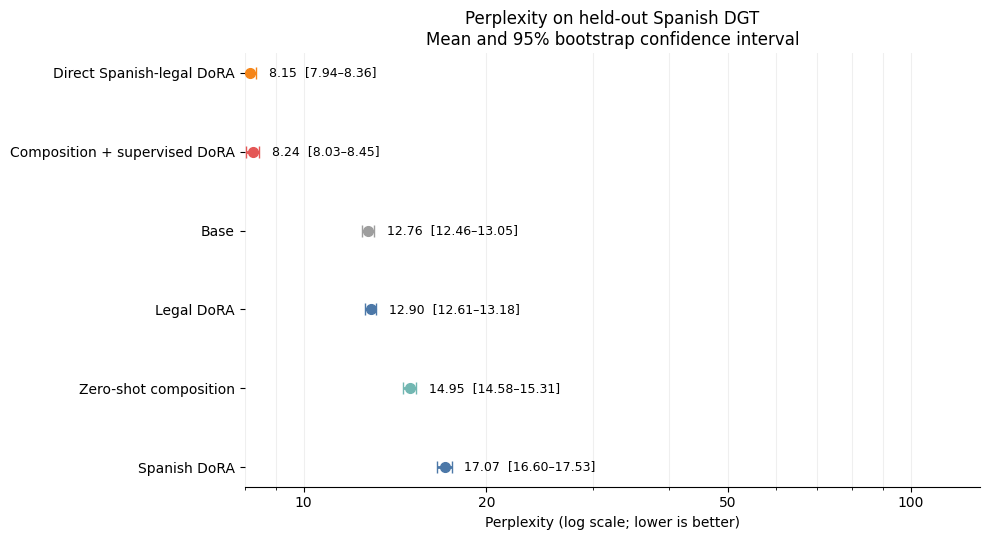

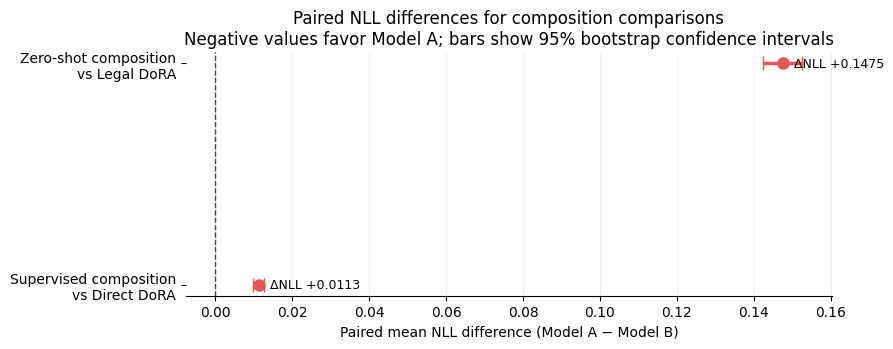

200

In [14]:
def paired_bootstrap_delta(losses_a, losses_b, samples=10_000, seed=SEED):
    """Estimate a paired NLL difference, confidence interval, and two-sided p-value."""
    assert len(losses_a) == len(losses_b)
    differences = losses_a - losses_b
    rng = np.random.default_rng(seed)
    boot_means = np.empty(samples, dtype=np.float64)
    for index in range(samples):
        boot_means[index] = rng.choice(
            differences,
            size=len(differences),
            replace=True,
        ).mean()

    ci_low, ci_high = np.quantile(boot_means, [0.025, 0.975])
    left = (np.count_nonzero(boot_means <= 0) + 1) / (samples + 1)
    right = (np.count_nonzero(boot_means >= 0) + 1) / (samples + 1)
    return {
        "delta_nll": float(differences.mean()),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "p_value": float(min(1.0, 2 * min(left, right))),
    }


# Build summary and paired-comparison tables from the shared held-out test set.
results = pd.DataFrame(result_rows).sort_values("perplexity").reset_index(drop=True)
base_ppl = float(results.loc[results["model"] == "Base", "perplexity"].iloc[0])
results["reduction_vs_base_pct"] = 100 * (1 - results["perplexity"] / base_ppl)

comparison_pairs = [
    ("Spanish DoRA", "Base"),
    ("Legal DoRA", "Base"),
    ("Zero-shot composition", "Legal DoRA"),
    ("Composition + supervised DoRA", "Direct Spanish-legal DoRA"),
]
comparisons = []
for model_a, model_b in comparison_pairs:
    stats = paired_bootstrap_delta(
        evaluation_losses[model_a],
        evaluation_losses[model_b],
    )
    comparisons.append({"model_a": model_a, "model_b": model_b, **stats})
comparisons = pd.DataFrame(comparisons)

# Keep readable notebook tables and full-precision result files.
results.to_csv(RESULT_DIR / "perplexity_results.csv", index=False)
comparisons.to_csv(RESULT_DIR / "paired_bootstrap_comparisons.csv", index=False)
np.savez_compressed(
    RESULT_DIR / "per_block_test_losses.npz",
    **{
        name.replace(" ", "_").replace("+", "plus"): losses
        for name, losses in evaluation_losses.items()
    },
)

results_view = pd.DataFrame({
    "Model": results["model"],
    "Mean NLL": results["mean_nll"].map(lambda value: f"{value:.4f}"),
    "Perplexity": results["perplexity"].map(lambda value: f"{value:.2f}"),
    "95% CI": results.apply(
        lambda row: f"{row.ppl_ci_low:.2f}–{row.ppl_ci_high:.2f}", axis=1
    ),
    "Reduction vs base": results["reduction_vs_base_pct"].map(
        lambda value: "—" if abs(value) < 1e-12 else f"{value:.1f}%"
    ),
})
display(results_view)

comparisons_view = pd.DataFrame({
    "Model A": comparisons["model_a"],
    "Model B": comparisons["model_b"],
    "Mean NLL difference (A − B)": comparisons["delta_nll"].map(
        lambda value: f"{value:.4f}"
    ),
    "95% paired CI": comparisons.apply(
        lambda row: f"[{row.ci_low:.4f}, {row.ci_high:.4f}]", axis=1
    ),
    "Two-sided p-value": comparisons["p_value"].map(lambda value: f"{value:.4f}"),
})
display(comparisons_view)
print("A negative NLL difference means Model A is better.")

# Plot overall perplexity on a log scale so the base model remains visible.
plot_data = results.sort_values("perplexity").reset_index(drop=True)
y = np.arange(len(plot_data))
colors = [
    "#E45756" if name == "Composition + supervised DoRA"
    else "#F58518" if name == "Direct Spanish-legal DoRA"
    else "#72B7B2" if name == "Zero-shot composition"
    else "#4C78A8" if name != "Base"
    else "#9E9E9E"
    for name in plot_data["model"]
]

fig, ax = plt.subplots(figsize=(10, 5.5))
for row_index, (row, color) in enumerate(zip(plot_data.itertuples(), colors)):
    ax.errorbar(
        row.perplexity,
        row_index,
        xerr=[
            [row.perplexity - row.ppl_ci_low],
            [row.ppl_ci_high - row.perplexity],
        ],
        fmt="o",
        color=color,
        ecolor=color,
        markersize=7,
        elinewidth=2,
        capsize=4,
    )

for row_index, row in plot_data.iterrows():
    ax.text(
        row.ppl_ci_high * 1.05,
        row_index,
        f"{row.perplexity:.2f}  [{row.ppl_ci_low:.2f}–{row.ppl_ci_high:.2f}]",
        va="center",
        fontsize=9,
    )

ax.set_xscale("log")
ax.set_xlim(8, max(130, plot_data["ppl_ci_high"].max() * 1.35))
ax.set_xticks([10, 20, 50, 100])
ax.set_xticklabels(["10", "20", "50", "100"])
ax.set_yticks(y)
ax.set_yticklabels(plot_data["model"])
ax.invert_yaxis()
ax.set_xlabel("Perplexity (log scale; lower is better)")
ax.set_title("Perplexity on held-out Spanish DGT\nMean and 95% bootstrap confidence interval")
ax.grid(axis="x", which="both", alpha=0.2)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
fig.savefig(RESULT_DIR / "perplexity_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Focus on the two composition decisions using paired block-level differences.
composition_plot = comparisons.loc[
    comparisons["model_b"] != "Base"
].reset_index(drop=True)
composition_labels = [
    "Zero-shot composition\nvs Legal DoRA",
    "Supervised composition\nvs Direct DoRA",
]

fig, ax = plt.subplots(figsize=(9, 3.6))
for row_index, row in composition_plot.iterrows():
    color = "#E45756" if row.delta_nll > 0 else "#4C78A8"
    ax.errorbar(
        row.delta_nll,
        row_index,
        xerr=[[row.delta_nll - row.ci_low], [row.ci_high - row.delta_nll]],
        fmt="o",
        color=color,
        ecolor=color,
        markersize=8,
        elinewidth=2.5,
        capsize=5,
    )
    offset = 8 if row.delta_nll >= 0 else -8
    alignment = "left" if row.delta_nll >= 0 else "right"
    ax.annotate(
        f"ΔNLL {row.delta_nll:+.4f}",
        (row.delta_nll, row_index),
        xytext=(offset, 0),
        textcoords="offset points",
        va="center",
        ha=alignment,
        fontsize=9,
    )

ax.axvline(0, color="#444444", linewidth=1, linestyle="--")
ax.set_yticks(np.arange(len(composition_plot)))
ax.set_yticklabels(composition_labels)
ax.invert_yaxis()
ax.set_xlabel("Paired mean NLL difference (Model A − Model B)")
ax.set_title(
    "Paired NLL differences for composition comparisons\n"
    "Negative values favor Model A; bars show 95% bootstrap confidence intervals"
)
ax.grid(axis="x", alpha=0.2)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
fig.savefig(
    RESULT_DIR / "paired_composition_differences.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

best_row = results.iloc[0]
summary = {
    "best_model": best_row["model"],
    "best_perplexity": float(best_row["perplexity"]),
    "base_perplexity": base_ppl,
    "target_train_word_count": target_word_counts["train"],
    "target_train_within_cap": target_word_counts["train"] <= TARGET_TRAIN_WORD_CAP,
}
(RESULT_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")


### Training dynamics

Training loss is logged during optimization, while validation loss is measured at each scheduled validation. The panels use separate vertical scales because the four starting points differ substantially.


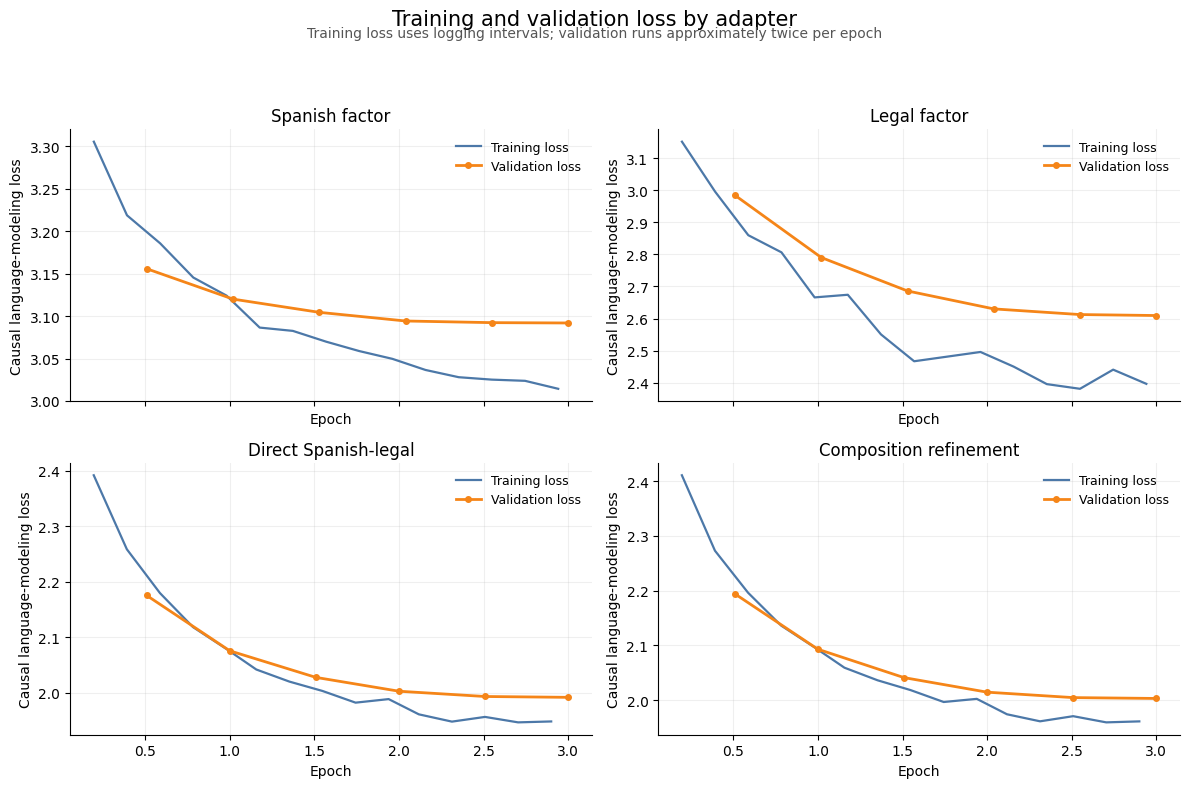

In [15]:
def load_training_history(run_name):
    """Return an in-memory training history or load its saved CSV file."""
    if run_name in training_histories:
        return training_histories[run_name].copy()
    history_path = RESULT_DIR / f"{run_name}_training_log.csv"
    return pd.read_csv(history_path) if history_path.exists() else pd.DataFrame()


# Compare optimization and validation curves for all four trained adapters.
history_runs = [
    ("language_spanish_books", "Spanish factor"),
    ("genre_non_spanish_dgt", "Legal factor"),
    ("target_spanish_dgt_direct", "Direct Spanish-legal"),
    ("composed_target_refinement", "Composition refinement"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (run_name, title) in zip(axes.flat, history_runs):
    history = load_training_history(run_name)
    plotted = False

    if not history.empty and {"epoch", "loss"}.issubset(history.columns):
        training_rows = history.loc[history["loss"].notna(), ["epoch", "loss"]]
        if not training_rows.empty:
            ax.plot(
                training_rows["epoch"],
                training_rows["loss"],
                color="#4C78A8",
                linewidth=1.6,
                label="Training loss",
            )
            plotted = True

    if not history.empty and {"epoch", "eval_loss"}.issubset(history.columns):
        validation_rows = history.loc[
            history["eval_loss"].notna(), ["epoch", "eval_loss"]
        ]
        if not validation_rows.empty:
            ax.plot(
                validation_rows["epoch"],
                validation_rows["eval_loss"],
                color="#F58518",
                marker="o",
                linewidth=2,
                markersize=4,
                label="Validation loss",
            )
            plotted = True

    if not plotted:
        ax.text(
            0.5,
            0.5,
            "No saved loss history",
            transform=ax.transAxes,
            ha="center",
            va="center",
            color="#666666",
        )
    else:
        ax.legend(frameon=False, fontsize=9)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Causal language-modeling loss")
    ax.grid(alpha=0.2)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

fig.suptitle("Training and validation loss by adapter", fontsize=15, y=0.98)
fig.text(
    0.5,
    0.945,
    "Training loss uses logging intervals; validation runs approximately twice per epoch",
    ha="center",
    fontsize=10,
    color="#555555",
)
plt.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(
    RESULT_DIR / "training_validation_loss.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 5. Source-domain sanity checks
These final comparisons check whether each factor adapter improves on its own held-out validation domain:

- Base vs. Spanish DoRA on Spanish Books.
- Base vs. Legal DoRA on non-Spanish DGT.

In [15]:
source_losses = {}

# Load the backbone once and evaluate it on both source domains.
print("Evaluating Base on Spanish Books...")
source_model = load_base()
source_losses[("Spanish Books", "Base")] = evaluate_block_losses(
    source_model,
    language_valid_blocks,
)

print("Evaluating Base on non-Spanish DGT...")
source_losses[("Non-Spanish DGT", "Base")] = evaluate_block_losses(
    source_model,
    genre_valid_blocks,
)
del source_model
clear_memory()

# Evaluate each factor adapter only on the domain used to train that factor.
print("Evaluating Spanish DoRA on Spanish Books...")
source_model = load_merged_adapter(LANGUAGE_ADAPTER)
source_losses[("Spanish Books", "Spanish DoRA")] = evaluate_block_losses(
    source_model,
    language_valid_blocks,
)
del source_model
clear_memory()

print("Evaluating Legal DoRA on non-Spanish DGT...")
source_model = load_merged_adapter(GENRE_ADAPTER)
source_losses[("Non-Spanish DGT", "Legal DoRA")] = evaluate_block_losses(
    source_model,
    genre_valid_blocks,
)
del source_model
clear_memory()

# Summarize NLL and perplexity using the bootstrap helper defined in Section 4.
source_rows = []
for (domain, model_name), losses in source_losses.items():
    mean_nll = float(losses.mean())
    ci_low, ci_high = bootstrap_ppl_ci(losses)
    source_rows.append({
        "domain": domain,
        "model": model_name,
        "mean_nll": mean_nll,
        "perplexity": float(np.exp(mean_nll)),
        "ppl_ci_low": ci_low,
        "ppl_ci_high": ci_high,
        "validation_blocks": len(losses),
    })

source_results = pd.DataFrame(source_rows)
base_perplexity = (
    source_results.loc[source_results["model"] == "Base"]
    .set_index("domain")["perplexity"]
)
source_results["ppl_change_vs_base_pct"] = source_results.apply(
    lambda row: 100 * (row.perplexity / base_perplexity[row.domain] - 1),
    axis=1,
)

# Use paired block losses because each adapter and Base see the same blocks.
source_comparison_rows = []
for domain, adapter_name in (
    ("Spanish Books", "Spanish DoRA"),
    ("Non-Spanish DGT", "Legal DoRA"),
):
    statistics = paired_bootstrap_delta(
        source_losses[(domain, adapter_name)],
        source_losses[(domain, "Base")],
    )
    source_comparison_rows.append({
        "domain": domain,
        "model_a": adapter_name,
        "model_b": "Base",
        **statistics,
    })

source_comparisons = pd.DataFrame(source_comparison_rows)

# Save full-precision outputs for the report.
source_results.to_csv(
    RESULT_DIR / "source_domain_results.csv",
    index=False,
)
source_comparisons.to_csv(
    RESULT_DIR / "source_domain_paired_comparisons.csv",
    index=False,
)
np.savez_compressed(
    RESULT_DIR / "source_domain_block_losses.npz",
    spanish_books_base=source_losses[("Spanish Books", "Base")],
    spanish_books_dora=source_losses[("Spanish Books", "Spanish DoRA")],
    non_spanish_dgt_base=source_losses[("Non-Spanish DGT", "Base")],
    non_spanish_dgt_dora=source_losses[("Non-Spanish DGT", "Legal DoRA")],
)

source_results_view = pd.DataFrame({
    "Validation domain": source_results["domain"],
    "Model": source_results["model"],
    "Mean NLL": source_results["mean_nll"].map(lambda value: f"{value:.4f}"),
    "Perplexity": source_results["perplexity"].map(lambda value: f"{value:.2f}"),
    "95% CI": source_results.apply(
        lambda row: f"{row.ppl_ci_low:.2f}–{row.ppl_ci_high:.2f}",
        axis=1,
    ),
    "PPL change vs base": source_results["ppl_change_vs_base_pct"].map(
        lambda value: "—" if abs(value) < 1e-12 else f"{value:+.1f}%"
    ),
})
display(source_results_view)

source_comparisons_view = pd.DataFrame({
    "Validation domain": source_comparisons["domain"],
    "Model A": source_comparisons["model_a"],
    "Model B": source_comparisons["model_b"],
    "Mean NLL difference (A − B)": source_comparisons["delta_nll"].map(
        lambda value: f"{value:+.4f}"
    ),
    "95% paired CI": source_comparisons.apply(
        lambda row: f"[{row.ci_low:+.4f}, {row.ci_high:+.4f}]",
        axis=1,
    ),
    "Two-sided p-value": source_comparisons["p_value"].map(
        lambda value: f"{value:.4f}"
    ),
})
display(source_comparisons_view)
print("A negative NLL difference means the factor adapter is better than Base on its own domain.")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

,Validation domain,Model,Mean NLL,Perplexity,95% CI,PPL change vs base
0,Spanish Books,Base,3.4240,30.69,30.22–31.19,—
1,Non-Spanish DGT,Base,3.3467,28.41,25.83–31.29,—
2,Spanish Books,Spanish DoRA,3.2446,25.65,25.27–26.04,-16.4%
3,Non-Spanish DGT,Legal DoRA,2.6829,14.63,13.81–15.50,-48.5%


,Validation domain,Model A,Model B,Mean NLL difference (A − B),95% paired CI,Two-sided p-value
0,Spanish Books,Spanish DoRA,Base,-0.1794,"[-0.1881, -0.1710]",0.0002
1,Non-Spanish DGT,Legal DoRA,Base,-0.6637,"[-0.7175, -0.6124]",0.0002


A negative NLL difference means the factor adapter is better than Base on its own domain.
